# P300 Classification — Brain Invaders (bi2015a)

**Research question:** How do ERP waveform, delta-band waveform, theta-band waveform, and combined delta+theta waveform feature representations compare in cross-subject target/non-target classification in the Brain Invaders bi2015a visual P300 dataset, and does their relative performance differ across 50 ms, 80 ms, and 110 ms flash-duration conditions?

**Method:** Leave-one-subject-out (LOSO) cross-validation · StandardScaler → Shrinkage LDA (solver=lsqr, shrinkage=auto) · ROC-AUC + balanced accuracy

In [37]:
import subprocess, sys

for pkg, import_name in [("pingouin", "pingouin"), ("statsmodels", "statsmodels")]:
    try:
        mod = __import__(import_name)
        print(f"{pkg} {mod.__version__} already installed")
    except ImportError:
        print(f"Installing {pkg}...")
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
        mod = __import__(import_name)
        print(f"{pkg} {mod.__version__} installed")

pingouin 0.5.5 already installed
statsmodels 0.14.0 already installed


In [ ]:
%matplotlib inline
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pingouin as pg

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, balanced_accuracy_score, roc_curve

from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests

OUTPUT_ROOT = Path().resolve() / "data" / "preprocessed"

VALID_SUBJECTS    = [s for s in range(2, 44) if s not in [1, 7, 11, 18, 27, 29]]
SESSIONS          = [1, 2, 3]
FLASH_DURATION_MS = {1: 110, 2: 80, 3: 50}
FEATURE_KEYS  = ["erp", "delta_wave", "theta_wave", "dt_wave"]
FEATURE_NAMES = ["ERP", "Delta Wave", "Theta Wave", "DT Wave"]
ALL_CH_NAMES = [
    'FP1', 'FP2', 'AFz', 'F7',  'F3',  'F4',  'F8',
    'FC5', 'FC1', 'FC2', 'FC6', 'T7',  'C3',  'Cz',  'C4',  'T8',
    'CP5', 'CP1', 'CP2', 'CP6', 'P7',  'P3',  'Pz',  'P4',  'P8',
    'PO7', 'O1',  'Oz',  'O2',  'PO8', 'PO9', 'PO10',
]
PZ_IDX    = ALL_CH_NAMES.index('Pz')   # = 22

## 1. Load All Features

Load the .npz feature archives from 00_batch_feature_extraction.py. Each file contains four feature matrices and binary target labels.

In [39]:
all_data = {}
skipped  = []

for s in VALID_SUBJECTS:
    all_data[s] = {}
    for ses in SESSIONS:
        path = OUTPUT_ROOT / f"subject_{s:02d}_session_{ses:02d}_features.npz"
        if not path.exists():
            skipped.append((s, ses, "file missing"))
            continue
        d = np.load(path)
        n = len(d['labels'])
        if n < 20:
            skipped.append((s, ses, f"{n} epochs < 20"))
            continue
        all_data[s][ses] = {k: d[k] for k in d.files}

n_subjects = sum(1 for s in all_data if all_data[s])
print(f"Loaded data for {n_subjects} subjects × {len(SESSIONS)} sessions")
if skipped:
    for item in skipped:
        print(f"  Skipped S{item[0]:02d} ses{item[1]}: {item[2]}")

Loaded data for 37 subjects × 3 sessions


In [40]:
rows = []
for s in VALID_SUBJECTS:
    if not all_data.get(s):
        continue
    row = {'Subject': f"{s:02d}"}
    for ses in SESSIONS:
        flash_ms = FLASH_DURATION_MS[ses]
        col = f"Ses{ses} ({flash_ms}ms)"
        if ses in all_data[s]:
            n = len(all_data[s][ses]['labels'])
            t = int(all_data[s][ses]['labels'].sum())
            row[col] = f"{n} ({t}T)"
        else:
            row[col] = "—"
    rows.append(row)

df_summary = pd.DataFrame(rows).set_index('Subject')
print(df_summary.to_string())

        Ses1 (110ms)  Ses2 (80ms) Ses3 (50ms)
Subject                                      
02         454 (76T)    440 (74T)   533 (89T)
03         125 (18T)    133 (22T)     53 (8T)
04         113 (22T)    483 (78T)   495 (82T)
05          83 (10T)      54 (9T)    72 (13T)
06         186 (34T)    178 (27T)   218 (39T)
08         419 (70T)    495 (82T)   576 (96T)
09         535 (89T)    326 (57T)   396 (66T)
10         289 (48T)    373 (62T)   343 (55T)
12        897 (151T)   647 (109T)   595 (97T)
13         367 (56T)    286 (45T)   312 (48T)
14         435 (73T)    387 (65T)   404 (68T)
15         335 (56T)    387 (64T)   484 (80T)
16         384 (64T)    343 (57T)   451 (76T)
17         589 (97T)    413 (69T)   472 (79T)
19         539 (90T)   631 (107T)   539 (90T)
20         359 (58T)    533 (88T)   548 (91T)
21         360 (60T)    394 (65T)   497 (83T)
22         491 (82T)    534 (89T)   539 (90T)
23         453 (73T)    376 (65T)   277 (46T)
24         388 (65T)    432 (72T) 

## 2. Protocol A — LOSO Cross-Validation (Cross-Subject Generalisation)

**Leave-one-subject-out (LOSO)** cross-validation tests cross-subject generalisation: train on all subjects except one, test on the held-out subject. This ensures no subject-specific patterns leak into the test set.

In [41]:
results = {ses: {fk: {} for fk in FEATURE_KEYS} for ses in SESSIONS}

for session in SESSIONS:
    flash_ms = FLASH_DURATION_MS[session]
    print(f"\n=== Session {session} ({flash_ms} ms flash) ===")
    subjects_with_data = [s for s in VALID_SUBJECTS if session in all_data.get(s, {})]

    for feat_key, feat_name in zip(FEATURE_KEYS, FEATURE_NAMES):
        auc_scores      = []
        bal_acc_scores  = []
        tested_subjects = []
        y_true_all      = []
        y_prob_all      = []

        for test_subject in subjects_with_data:
            X_train_list, y_train_list = [], []
            for train_subject in subjects_with_data:
                if train_subject == test_subject:
                    continue
                X_train_list.append(all_data[train_subject][session][feat_key])
                y_train_list.append(all_data[train_subject][session]['labels'])

            X_train = np.vstack(X_train_list)
            y_train = np.concatenate(y_train_list)
            X_test  = all_data[test_subject][session][feat_key]
            y_test  = all_data[test_subject][session]['labels']

            if len(np.unique(y_test)) < 2:
                continue

            # priors=[0.5, 0.5] is the LDA-native class_weight='balanced' equivalent
            clf = make_pipeline(
                StandardScaler(),
                LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto',
                                           priors=[0.5, 0.5]),
            )
            clf.fit(X_train, y_train)

            y_prob = clf.predict_proba(X_test)[:, 1]
            y_pred = clf.predict(X_test)

            auc_scores.append(roc_auc_score(y_test, y_prob))
            bal_acc_scores.append(balanced_accuracy_score(y_test, y_pred))
            tested_subjects.append(test_subject)
            y_true_all.extend(y_test.tolist())
            y_prob_all.extend(y_prob.tolist())

        results[session][feat_key] = {
            'auc':      np.array(auc_scores),
            'bal_acc':  np.array(bal_acc_scores),
            'subjects': tested_subjects,
            'y_true':   np.array(y_true_all),
            'y_prob':   np.array(y_prob_all),
        }
        print(f"  {feat_name:15s} — mean AUC: {np.mean(auc_scores):.3f} ± {np.std(auc_scores):.3f}")

print("\nLOSO classification complete.")


=== Session 1 (110 ms flash) ===
  ERP             — mean AUC: 0.833 ± 0.090
  Delta Wave      — mean AUC: 0.773 ± 0.095
  Theta Wave      — mean AUC: 0.607 ± 0.060
  DT Wave         — mean AUC: 0.779 ± 0.085

=== Session 2 (80 ms flash) ===
  ERP             — mean AUC: 0.836 ± 0.082
  Delta Wave      — mean AUC: 0.778 ± 0.099
  Theta Wave      — mean AUC: 0.632 ± 0.059
  DT Wave         — mean AUC: 0.780 ± 0.091

=== Session 3 (50 ms flash) ===
  ERP             — mean AUC: 0.832 ± 0.088
  Delta Wave      — mean AUC: 0.769 ± 0.088
  Theta Wave      — mean AUC: 0.651 ± 0.065
  DT Wave         — mean AUC: 0.781 ± 0.080

LOSO classification complete.


## 2b. Protocol B — Within-Subject 5-Fold Stratified Cross-Validation

**Protocol B** estimates each subject's *personal* classifier performance by training and testing entirely within the same subject using **5-fold stratified cross-validation** (StratifiedKFold, shuffle, random_state=42). This measures within-subject discriminability — the upper bound a deployed BCI could achieve with personal calibration data.

In [42]:
K_FOLDS = 5
within_results = {ses: {fk: {} for fk in FEATURE_KEYS} for ses in SESSIONS}

for session in SESSIONS:
    flash_ms = FLASH_DURATION_MS[session]
    print(f"\n=== Session {session} ({flash_ms} ms flash) — Protocol B (within-subject k={K_FOLDS}) ===")
    subjects_with_data = [s for s in VALID_SUBJECTS if session in all_data.get(s, {})]

    for feat_key, feat_name in zip(FEATURE_KEYS, FEATURE_NAMES):
        auc_scores      = []
        tested_subjects = []

        for subject in subjects_with_data:
            X = all_data[subject][session][feat_key]
            y = all_data[subject][session]['labels']

            if len(np.unique(y)) < 2 or len(y) < K_FOLDS * 2:
                continue

            skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=42)
            fold_aucs = []

            for train_idx, test_idx in skf.split(X, y):
                X_tr, X_te = X[train_idx], X[test_idx]
                y_tr, y_te = y[train_idx], y[test_idx]

                if len(np.unique(y_te)) < 2:
                    continue

                clf = make_pipeline(
                    StandardScaler(),
                    LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto',
                                               priors=[0.5, 0.5]),
                )
                clf.fit(X_tr, y_tr)
                fold_aucs.append(roc_auc_score(y_te, clf.predict_proba(X_te)[:, 1]))

            if fold_aucs:
                auc_scores.append(np.mean(fold_aucs))
                tested_subjects.append(subject)

        within_results[session][feat_key] = {
            'auc':      np.array(auc_scores),
            'subjects': tested_subjects,
        }
        print(f"  {feat_name:15s} — mean AUC: {np.mean(auc_scores):.3f} ± {np.std(auc_scores):.3f}")

print("\nWithin-subject k-fold classification complete.")


=== Session 1 (110 ms flash) — Protocol B (within-subject k=5) ===
  ERP             — mean AUC: 0.819 ± 0.091
  Delta Wave      — mean AUC: 0.819 ± 0.083
  Theta Wave      — mean AUC: 0.611 ± 0.094
  DT Wave         — mean AUC: 0.800 ± 0.089

=== Session 2 (80 ms flash) — Protocol B (within-subject k=5) ===
  ERP             — mean AUC: 0.824 ± 0.097
  Delta Wave      — mean AUC: 0.801 ± 0.093
  Theta Wave      — mean AUC: 0.632 ± 0.079
  DT Wave         — mean AUC: 0.800 ± 0.081

=== Session 3 (50 ms flash) — Protocol B (within-subject k=5) ===
  ERP             — mean AUC: 0.830 ± 0.088
  Delta Wave      — mean AUC: 0.792 ± 0.076
  Theta Wave      — mean AUC: 0.637 ± 0.081
  DT Wave         — mean AUC: 0.795 ± 0.084

Within-subject k-fold classification complete.


## 3. Results Tables

### 3a. Protocol A — LOSO (Cross-Subject) ROC-AUC

Mean ROC-AUC ± SD across subjects for all 4 bandpass waveform feature sets × 3 flash durations. All cells use StandardScaler → Shrinkage LDA with balanced sample weights. Cells coloured **green** if feature beats ERP, **red** if not.

### 3b. Protocol B — Within-Subject 5-Fold ROC-AUC

Same layout but for within-subject stratified k-fold (k=5). Higher values than Protocol A reveal subject-specific signal not captured by a cross-subject model (see Section 3c for the gap).

In [43]:
conditions = ["110ms", "80ms", "50ms"]

# ── Protocol A (LOSO) ──────────────────────────────────────────────────────────
loso_table = {}
for feat_name, feat_key in zip(FEATURE_NAMES, FEATURE_KEYS):
    row = {}
    for session in SESSIONS:
        flash_ms = FLASH_DURATION_MS[session]
        aucs = results[session][feat_key]['auc']
        row[f"{flash_ms}ms"] = f"{np.mean(aucs):.3f} ± {np.std(aucs):.3f}"
    loso_table[feat_name] = row

df_loso = pd.DataFrame(loso_table).T[conditions]
print("Protocol A — LOSO (cross-subject) ROC-AUC:")
print(df_loso.to_string())

# ── Protocol B (within-subject) ───────────────────────────────────────────────
within_table = {}
for feat_name, feat_key in zip(FEATURE_NAMES, FEATURE_KEYS):
    row = {}
    for session in SESSIONS:
        flash_ms = FLASH_DURATION_MS[session]
        aucs = within_results[session][feat_key]['auc']
        row[f"{flash_ms}ms"] = f"{np.mean(aucs):.3f} ± {np.std(aucs):.3f}"
    within_table[feat_name] = row

df_within = pd.DataFrame(within_table).T[conditions]
print("\nProtocol B — Within-subject 5-fold ROC-AUC:")
print(df_within.to_string())

Protocol A — LOSO (cross-subject) ROC-AUC:
                    110ms           80ms           50ms
ERP         0.833 ± 0.090  0.836 ± 0.082  0.832 ± 0.088
Delta Wave  0.773 ± 0.095  0.778 ± 0.099  0.769 ± 0.088
Theta Wave  0.607 ± 0.060  0.632 ± 0.059  0.651 ± 0.065
DT Wave     0.779 ± 0.085  0.780 ± 0.091  0.781 ± 0.080

Protocol B — Within-subject 5-fold ROC-AUC:
                    110ms           80ms           50ms
ERP         0.819 ± 0.091  0.824 ± 0.097  0.830 ± 0.088
Delta Wave  0.819 ± 0.083  0.801 ± 0.093  0.792 ± 0.076
Theta Wave  0.611 ± 0.094  0.632 ± 0.079  0.637 ± 0.081
DT Wave     0.800 ± 0.089  0.800 ± 0.081  0.795 ± 0.084


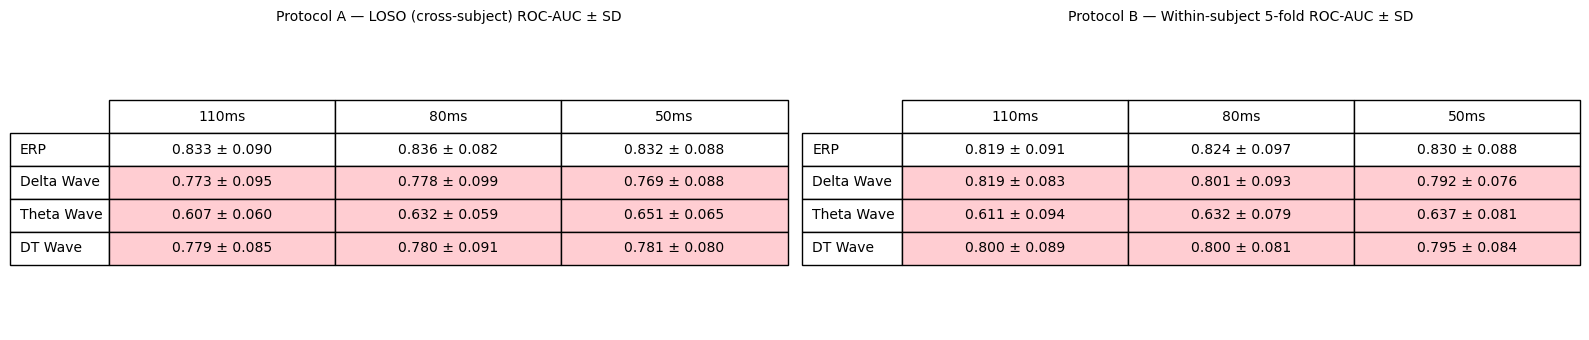

In [44]:
erp_means = {cond: float(df_loso.loc["ERP", cond].split(" ± ")[0]) for cond in conditions}
within_erp = {cond: float(df_within.loc["ERP", cond].split(" ± ")[0]) for cond in conditions}

def make_colour_table(df_vals, erp_ref):
    cell_text, cell_colors = [], []
    for feat_name in FEATURE_NAMES:
        row_text, row_colors = [], []
        for cond in conditions:
            val_str = df_vals.loc[feat_name, cond]
            mean_val = float(val_str.split(" ± ")[0])
            row_text.append(val_str)
            if feat_name == "ERP":
                row_colors.append('#FFFFFF')
            elif mean_val > erp_ref[cond]:
                row_colors.append('#C8E6C9')
            else:
                row_colors.append('#FFCDD2')
        cell_text.append(row_text)
        cell_colors.append(row_colors)
    return cell_text, cell_colors

fig, axes = plt.subplots(1, 2, figsize=(16, 3.5))
for ax, (df_vals, erp_ref, title) in zip(axes, [
    (df_loso,   erp_means, "Protocol A — LOSO (cross-subject) ROC-AUC ± SD"),
    (df_within, within_erp, "Protocol B — Within-subject 5-fold ROC-AUC ± SD"),
]):
    ct, cc = make_colour_table(df_vals, erp_ref)
    ax.axis('off')
    tbl = ax.table(cellText=ct, rowLabels=FEATURE_NAMES, colLabels=conditions,
                   cellColours=cc, loc='center', cellLoc='center')
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(10)
    tbl.scale(1, 1.8)
    ax.set_title(title, fontsize=10, pad=10)

plt.tight_layout()
plt.show()

### 3c. Generalisation Gap Table

**Within-subject AUC (Protocol B) − Cross-subject AUC (Protocol A)** per feature per flash duration.

A positive gap means subject-specific calibration adds value beyond a cross-subject model — the larger the gap, the more personalisation matters for that feature × condition cell.

Generalisation Gap (Protocol B − Protocol A mean AUC):
             110ms    80ms    50ms
ERP         -0.015  -0.012  -0.002
Delta Wave  +0.046  +0.023  +0.022
Theta Wave  +0.004  +0.001  -0.014
DT Wave     +0.021  +0.020  +0.014


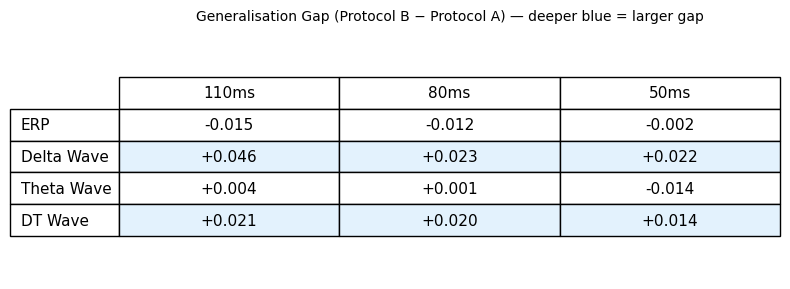

In [45]:
gap_rows = {}
for feat_name, feat_key in zip(FEATURE_NAMES, FEATURE_KEYS):
    row = {}
    for session in SESSIONS:
        flash_ms  = FLASH_DURATION_MS[session]
        cond      = f"{flash_ms}ms"
        loso_auc  = np.mean(results[session][feat_key]['auc'])
        within_auc = np.mean(within_results[session][feat_key]['auc'])
        row[cond] = within_auc - loso_auc
    gap_rows[feat_name] = row

df_gap = pd.DataFrame(gap_rows).T[conditions]

print("Generalisation Gap (Protocol B − Protocol A mean AUC):")
print(df_gap.applymap(lambda x: f"{x:+.3f}").to_string())

# Coloured table: blue = gap > 0.05 (large), light = moderate, near-zero = white
def gap_colour(val):
    if val >= 0.10:  return '#1565C0'   # deep blue — large gap
    if val >= 0.05:  return '#90CAF9'   # light blue — moderate gap
    if val >= 0.01:  return '#E3F2FD'   # very light blue — small gap
    return '#FFFFFF'

cell_text   = [[f"{df_gap.loc[fn, c]:+.3f}" for c in conditions] for fn in FEATURE_NAMES]
cell_colors = [[gap_colour(df_gap.loc[fn, c])  for c in conditions] for fn in FEATURE_NAMES]

fig, ax = plt.subplots(figsize=(8, 3))
ax.axis('off')
tbl = ax.table(cellText=cell_text, rowLabels=FEATURE_NAMES, colLabels=conditions,
               cellColours=cell_colors, loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1, 1.8)
ax.set_title("Generalisation Gap (Protocol B − Protocol A) — deeper blue = larger gap",
             fontsize=10, pad=10)
plt.tight_layout()
plt.show()

## 4. Visualisations

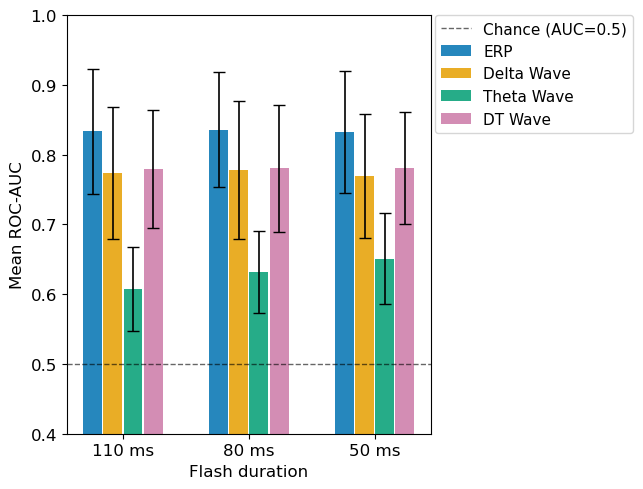

In [46]:
import os
os.makedirs("figures", exist_ok=True)

# Colourblind-safe palette from Wong (2011), Nature Methods
PUB_COLORS = {
    "ERP":        "#0072B2",  # blue
    "Delta Wave": "#E69F00",  # orange
    "Theta Wave": "#009E73",  # green
    "DT Wave":    "#CC79A7",  # pink/purple
}

n_feat   = len(FEATURE_NAMES)
bar_w    = 0.15
x_ctr    = np.arange(len(SESSIONS))
offsets  = np.linspace(-(n_feat - 1) / 2, (n_feat - 1) / 2, n_feat) * (bar_w + 0.01)

fig, ax = plt.subplots(figsize=(8, 5))
for i, (feat_name, feat_key) in enumerate(zip(FEATURE_NAMES, FEATURE_KEYS)):
    means = [np.mean(results[s][feat_key]['auc']) for s in SESSIONS]
    stds  = [np.std(results[s][feat_key]['auc'])  for s in SESSIONS]
    ax.bar(x_ctr + offsets[i], means, bar_w, yerr=stds,
           label=feat_name, color=PUB_COLORS[feat_name],
           capsize=4, alpha=0.85, error_kw={'linewidth': 1.2})

ax.axhline(0.5, color='black', linestyle='--', linewidth=1, alpha=0.6, label='Chance (AUC=0.5)')
ax.set_xticks(x_ctr)
ax.set_xticklabels([f"{FLASH_DURATION_MS[s]} ms" for s in SESSIONS], fontsize=12)
ax.tick_params(axis='y', labelsize=12)
ax.set_xlabel("Flash duration", fontsize=12)
ax.set_ylabel("Mean ROC-AUC", fontsize=12)
ax.set_ylim(0.4, 1.0)
ax.legend(fontsize=11, loc='upper left', bbox_to_anchor=(1.01, 1.0), borderaxespad=0)
plt.tight_layout(rect=[0, 0, 0.82, 1])
plt.savefig("figures/loso_barchart.pdf", dpi=300, bbox_inches='tight')
plt.savefig("figures/loso_barchart.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close('all')

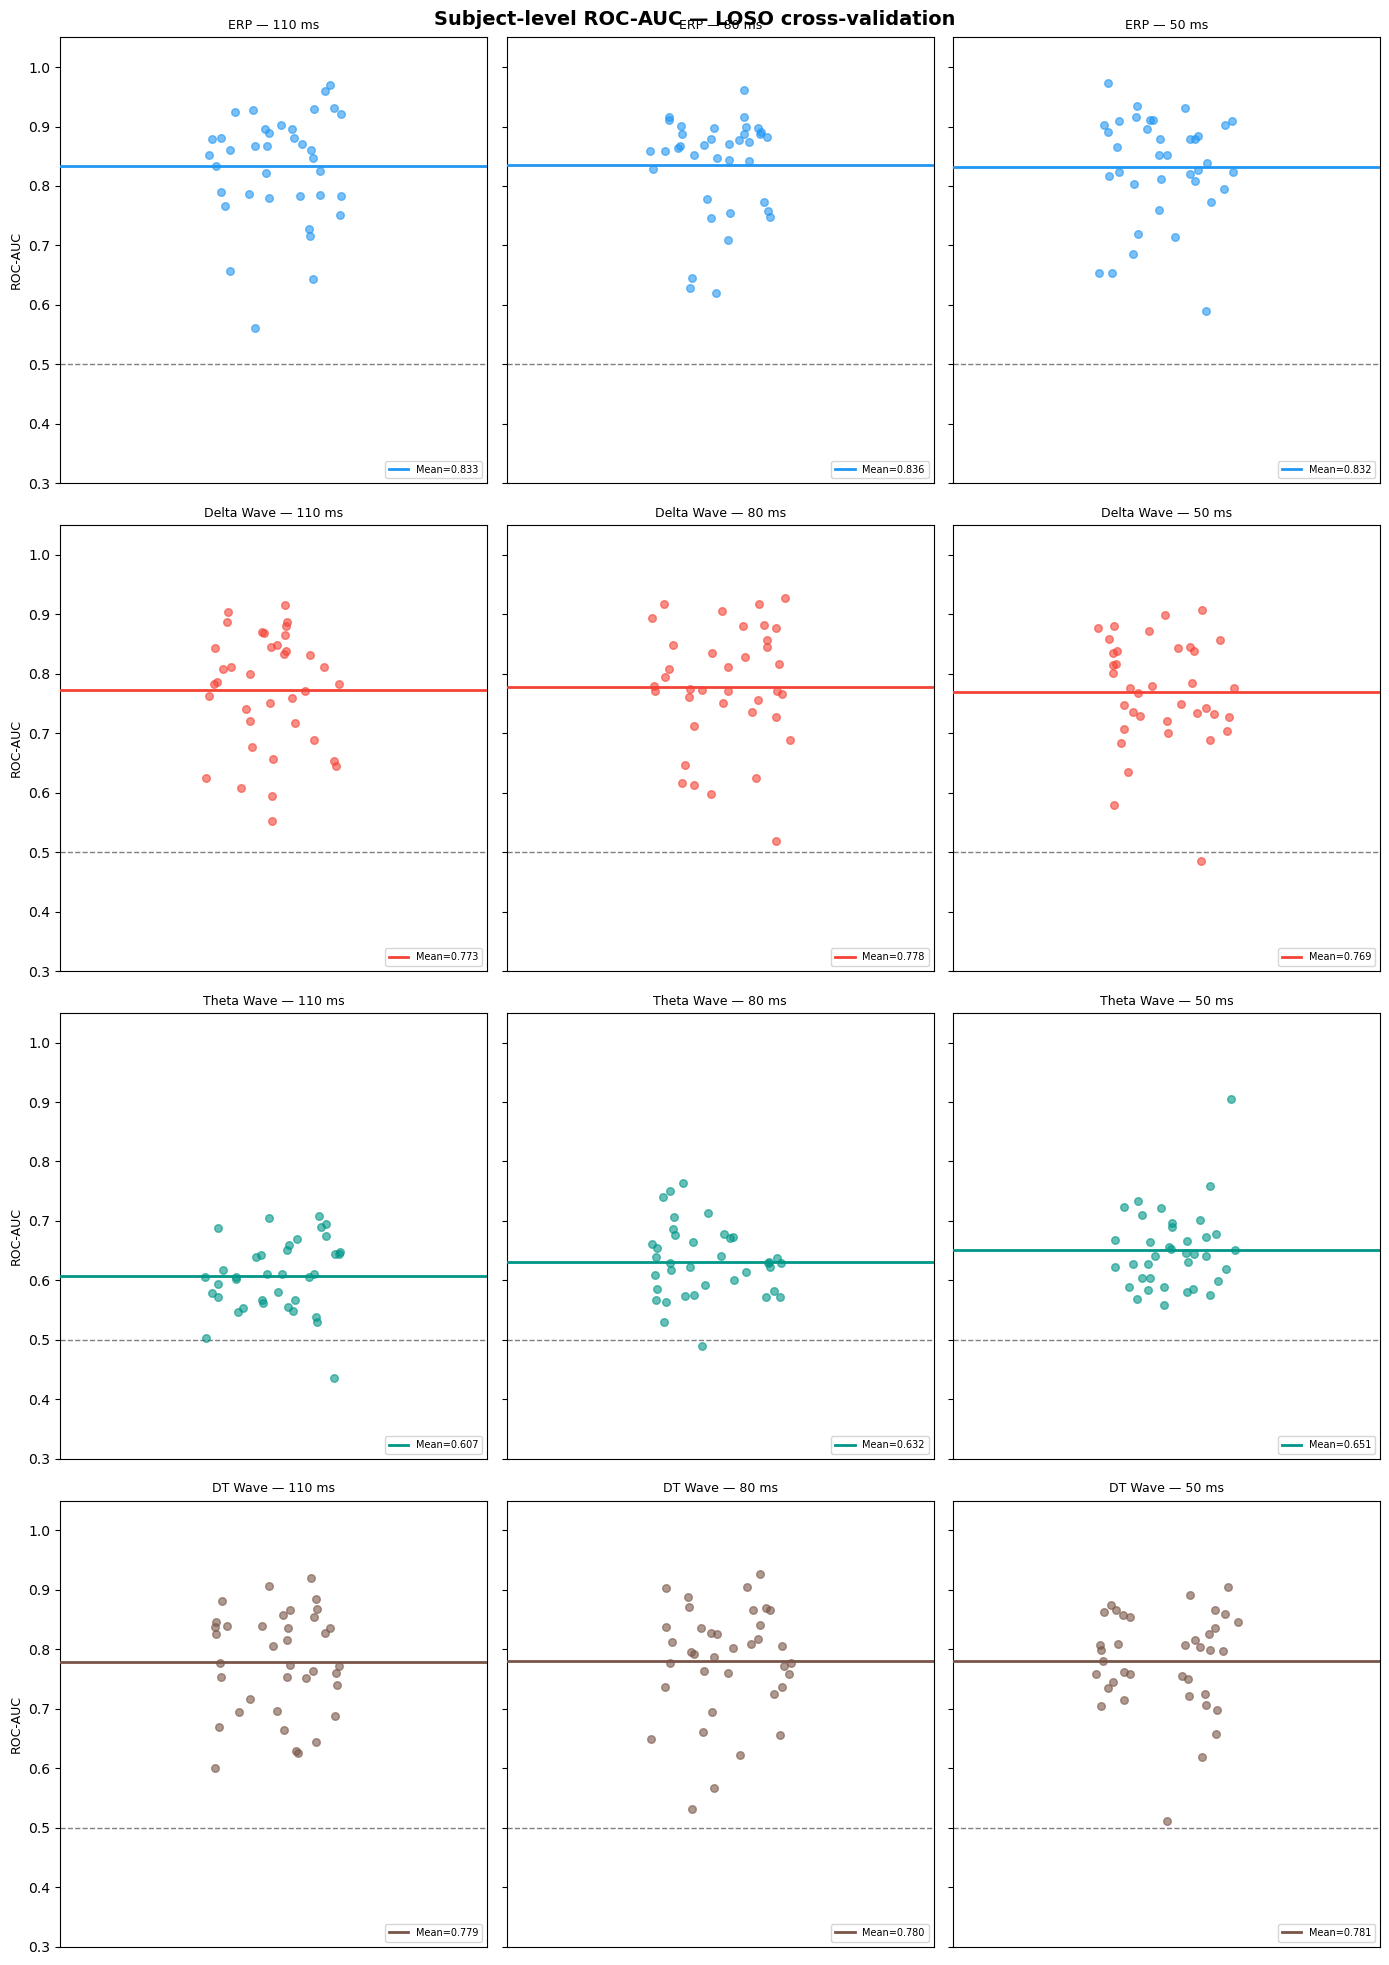

In [ ]:
rng = np.random.default_rng(42)
fig, axes = plt.subplots(len(FEATURE_NAMES), len(SESSIONS),
                         figsize=(14, 20), sharey=True)
fig.suptitle("Subject-level ROC-AUC — LOSO cross-validation",
             fontsize=14, fontweight='bold')

for ri, (feat_name, feat_key) in enumerate(zip(FEATURE_NAMES, FEATURE_KEYS)):
    for ci, session in enumerate(SESSIONS):
        ax       = axes[ri, ci]
        flash_ms = FLASH_DURATION_MS[session]
        aucs     = results[session][feat_key]['auc']
        jitter   = rng.uniform(-0.2, 0.2, len(aucs))
        ax.scatter(jitter, aucs, color=PUB_COLORS[feat_name], alpha=0.6, s=30, zorder=3)
        ax.axhline(np.mean(aucs), color=PUB_COLORS[feat_name], linewidth=2, zorder=4,
                   label=f"Mean={np.mean(aucs):.3f}")
        ax.axhline(0.5, color='black', linestyle='--', linewidth=1, alpha=0.5)
        ax.set_xlim(-0.6, 0.6)
        ax.set_ylim(0.3, 1.05)
        ax.set_xticks([])
        ax.set_title(f"{feat_name} — {flash_ms} ms", fontsize=9)
        if ci == 0:
            ax.set_ylabel("ROC-AUC", fontsize=9)
        ax.legend(fontsize=7, loc='lower right')

plt.tight_layout()
plt.show()
plt.close('all')

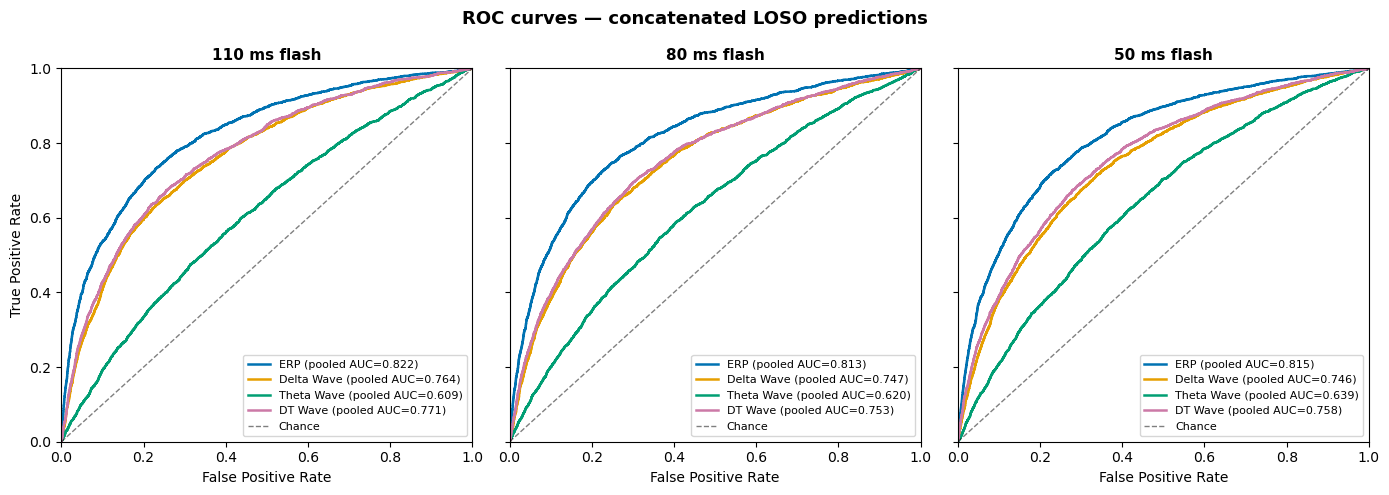

In [53]:
fig, axes = plt.subplots(1, len(SESSIONS), figsize=(14, 5), sharey=True)
fig.suptitle("ROC curves — concatenated LOSO predictions", fontsize=13, fontweight='bold')

for ci, session in enumerate(SESSIONS):
    ax       = axes[ci]
    flash_ms = FLASH_DURATION_MS[session]
    for feat_name, feat_key in zip(FEATURE_NAMES, FEATURE_KEYS):
        y_true = results[session][feat_key]['y_true']
        y_prob = results[session][feat_key]['y_prob']
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        auc = roc_auc_score(y_true, y_prob)
        ax.plot(fpr, tpr, color=PUB_COLORS[feat_name], linewidth=1.8,
                label=f"{feat_name} (pooled AUC={auc:.3f})")
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Chance')
    ax.set_xlabel("False Positive Rate", fontsize=10)
    if ci == 0:
        ax.set_ylabel("True Positive Rate", fontsize=10)
    ax.set_title(f"{flash_ms} ms flash", fontsize=11, fontweight='bold')
    ax.legend(fontsize=8, loc='lower right')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()
plt.close('all')

### 4d. Grand-Average ERP at Pz — Target vs Non-Target

Loads raw .fif files directly; plots amplitude in µV. Shading shows ±1 SD across subjects.

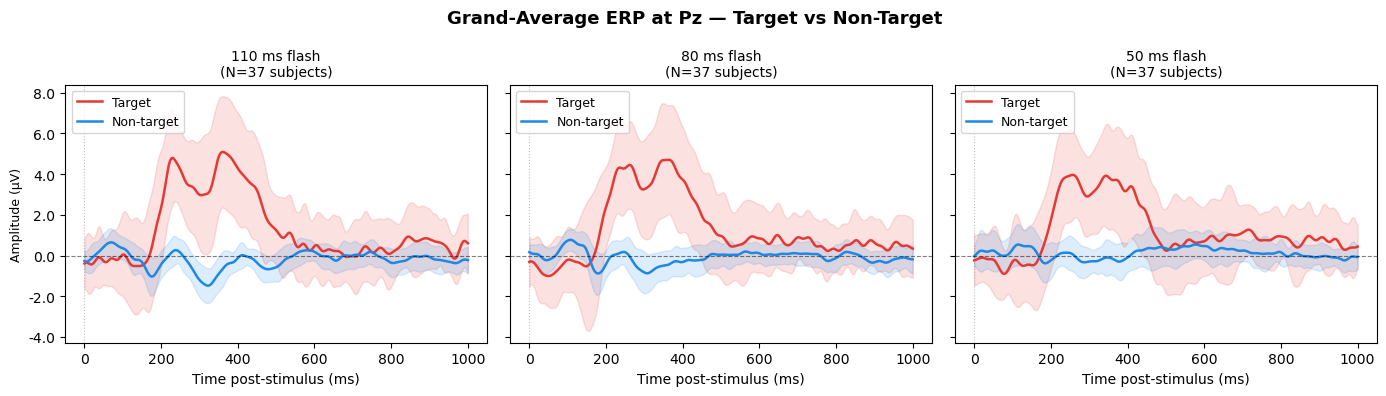

In [49]:
import mne

fig, axes = plt.subplots(1, len(SESSIONS), figsize=(14, 4), sharey=True)
fig.suptitle("Grand-Average ERP at Pz — Target vs Non-Target", fontsize=13, fontweight='bold')

for ci, session in enumerate(SESSIONS):
    ax       = axes[ci]
    flash_ms = FLASH_DURATION_MS[session]

    subj_target    = []
    subj_nontarget = []
    time_ms        = None
    n_valid        = 0

    for s in VALID_SUBJECTS:
        fif_path = OUTPUT_ROOT / f"subject_{s:02d}_session_{session:02d}_epo.fif"
        if not fif_path.exists():
            continue
        epochs = mne.read_epochs(fif_path, preload=True, verbose=False)
        epochs.crop(tmin=0.0, tmax=1.0)
        if time_ms is None:
            time_ms = epochs.times * 1000
        pz_data = epochs.get_data(picks=['Pz'])[:, 0, :] * 1e6  # (n_epochs, n_times) µV
        target_mask = epochs.metadata['target'].values.astype(bool)
        if target_mask.sum() > 0:
            subj_target.append(pz_data[target_mask].mean(axis=0))
        if (~target_mask).sum() > 0:
            subj_nontarget.append(pz_data[~target_mask].mean(axis=0))
        n_valid += 1

    tgt_arr = np.array(subj_target)
    nt_arr  = np.array(subj_nontarget)

    for arr, label, color in [
        (tgt_arr, 'Target',     '#E53935'),
        (nt_arr,  'Non-target', '#1E88E5'),
    ]:
        mean = arr.mean(axis=0)
        std  = arr.std(axis=0)
        ax.plot(time_ms, mean, color=color, linewidth=1.8, label=label)
        ax.fill_between(time_ms, mean - std, mean + std, color=color, alpha=0.15)

    ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.axvline(0, color='gray',  linewidth=0.8, linestyle=':',  alpha=0.5)
    ax.set_xlabel("Time post-stimulus (ms)", fontsize=10)
    ax.set_title(f"{flash_ms} ms flash\n(N={n_valid} subjects)", fontsize=10)
    if ci == 0:
        ax.set_ylabel("Amplitude (µV)", fontsize=9)
    ax.yaxis.set_major_formatter(plt.FormatStrFormatter('%.1f'))
    ax.legend(fontsize=9, loc='upper left')

plt.tight_layout()
plt.show()
plt.close('all')

## 5. Statistical Analysis — Repeated Measures ANOVA + Wilcoxon Post-Hoc

In [50]:
rows = []
for subject in VALID_SUBJECTS:
    for session in SESSIONS:
        flash_ms = FLASH_DURATION_MS[session]
        for feat_name, feat_key in zip(FEATURE_NAMES, FEATURE_KEYS):
            subs = results[session][feat_key].get('subjects', [])
            if subject not in subs:
                continue
            idx = subs.index(subject)
            rows.append({
                'subject':  subject,
                'feature':  feat_name,
                'flash_ms': str(flash_ms),
                'auc':      results[session][feat_key]['auc'][idx],
            })

df_long = pd.DataFrame(rows)

# Keep only subjects with data in every cell (required for balanced rm-ANOVA)
n_cells     = len(FEATURE_NAMES) * len(SESSIONS)
counts      = df_long.groupby('subject').size()
complete    = counts[counts == n_cells].index.tolist()
df_complete = df_long[df_long['subject'].isin(complete)].reset_index(drop=True)
print(f"Subjects with complete data (all 12 cells): {len(complete)} / {df_long['subject'].nunique()}")
print(df_complete.groupby(['feature', 'flash_ms'])['auc'].agg(['mean', 'std']).round(3).to_string())

Subjects with complete data (all 12 cells): 37 / 37
                      mean    std
feature    flash_ms              
DT Wave    110       0.779  0.086
           50        0.781  0.081
           80        0.780  0.092
Delta Wave 110       0.773  0.096
           50        0.769  0.090
           80        0.778  0.100
ERP        110       0.833  0.091
           50        0.832  0.089
           80        0.836  0.084
Theta Wave 110       0.607  0.061
           50        0.651  0.066
           80        0.632  0.060


In [51]:
aov = pg.rm_anova(
    data=df_complete,
    dv='auc',
    within=['feature', 'flash_ms'],
    subject='subject',
    detailed=True,
)
# pingouin ≥0.5 uses 'ng2' (generalized eta²); older versions used 'np2'
eta_col = 'ng2' if 'ng2' in aov.columns else ('np2' if 'np2' in aov.columns else aov.columns[-1])
print(aov[['Source', 'ddof1', 'ddof2', 'F', 'p-unc', eta_col]].to_string(index=False))

            Source  ddof1  ddof2          F        p-unc      ng2
           feature      3    108 113.969951 2.508360e-33 0.453974
          flash_ms      2     72   1.131153 3.283268e-01 0.002851
feature * flash_ms      6    216   3.803323 1.266785e-03 0.009323


In [52]:
interaction_rows = aov[aov['Source'].str.contains('feature') & aov['Source'].str.contains('flash')]
interaction_p    = interaction_rows['p-unc'].values

if len(interaction_p) == 0 or interaction_p[0] >= 0.05:
    p_str = f"{interaction_p[0]:.4f}" if len(interaction_p) > 0 else "N/A"
    print(f"Interaction NOT significant (p = {p_str}). No post-hoc needed.")
else:
    print(f"Interaction significant (p = {interaction_p[0]:.4e}) — running Wilcoxon signed-rank post-hoc with FDR\n")

    # All pairs of features
    pairs = [(FEATURE_NAMES[i], FEATURE_NAMES[j])
             for i in range(len(FEATURE_NAMES))
             for j in range(i + 1, len(FEATURE_NAMES))]

    wilcox_rows = []
    for session in SESSIONS:
        flash_ms = FLASH_DURATION_MS[session]
        for fn_a, fn_b in pairs:
            fk_a = FEATURE_KEYS[FEATURE_NAMES.index(fn_a)]
            fk_b = FEATURE_KEYS[FEATURE_NAMES.index(fn_b)]

            subs_a = results[session][fk_a]['subjects']
            subs_b = results[session][fk_b]['subjects']
            common = sorted(set(subs_a) & set(subs_b))
            if len(common) < 5:
                continue

            aucs_a = np.array([results[session][fk_a]['auc'][subs_a.index(s)] for s in common])
            aucs_b = np.array([results[session][fk_b]['auc'][subs_b.index(s)] for s in common])

            stat, p_unc = wilcoxon(aucs_a, aucs_b)
            wilcox_rows.append({
                'flash_ms': f"{flash_ms}ms",
                'A': fn_a, 'B': fn_b,
                'mean_A': np.mean(aucs_a), 'mean_B': np.mean(aucs_b),
                'W': stat, 'p_unc': p_unc,
            })

    df_wilcox = pd.DataFrame(wilcox_rows)
    _, p_fdr, _, _ = multipletests(df_wilcox['p_unc'], method='fdr_bh')
    df_wilcox['p_fdr'] = p_fdr
    df_wilcox['sig'] = df_wilcox['p_fdr'] < 0.05

    # Display full table
    display_cols = ['flash_ms', 'A', 'B', 'mean_A', 'mean_B', 'W', 'p_unc', 'p_fdr', 'sig']
    pd.set_option('display.float_format', '{:.4f}'.format)
    print("All pairwise Wilcoxon signed-rank tests (FDR-corrected):")
    print(df_wilcox[display_cols].to_string(index=False))

    sig_tests = df_wilcox[df_wilcox['sig']]
    print(f"\n{len(sig_tests)} / {len(df_wilcox)} tests survive FDR correction (q < 0.05)")
    pd.reset_option('display.float_format')

Interaction significant (p = 1.2668e-03) — running Wilcoxon signed-rank post-hoc with FDR

All pairwise Wilcoxon signed-rank tests (FDR-corrected):
flash_ms          A          B  mean_A  mean_B        W  p_unc  p_fdr   sig
   110ms        ERP Delta Wave  0.8331  0.7734  91.0000 0.0001 0.0001  True
   110ms        ERP Theta Wave  0.8331  0.6072   3.0000 0.0000 0.0000  True
   110ms        ERP    DT Wave  0.8331  0.7787  87.0000 0.0001 0.0001  True
   110ms Delta Wave Theta Wave  0.7734  0.6072  23.0000 0.0000 0.0000  True
   110ms Delta Wave    DT Wave  0.7734  0.7787 239.0000 0.0897 0.0949 False
   110ms Theta Wave    DT Wave  0.6072  0.7787  13.0000 0.0000 0.0000  True
    80ms        ERP Delta Wave  0.8359  0.7783 101.0000 0.0002 0.0002  True
    80ms        ERP Theta Wave  0.8359  0.6316   1.0000 0.0000 0.0000  True
    80ms        ERP    DT Wave  0.8359  0.7803  88.0000 0.0001 0.0001  True
    80ms Delta Wave Theta Wave  0.7783  0.6316  14.0000 0.0000 0.0000  True
    80ms Delta W